# INFO 2950 Final Project Phase IV

## Table of Contents
- [Introduction](#introduction)
- [Data Description and Cleaning](#data-description-and-cleaning)
    - [Motivation](#motivation)
    - [Composition](#composition)
    - [Collection Process](#collection-process)
    - [Preprocessing/Cleaning/Labeling](#preprocessingcleaninglabeling)
- [Preregistration Statement](#preregistration-statement)
    - [Statement 1](#statement-1)
    - [Statement 2](#statement-2)
- [Data Analysis](#data-analysis)
    - [Statement 1 Analysis](#statement-1-analysis)
    - [Statement 2 Analysis](#statement-2-analysis)
- [Evaluation of Significance](#evaluation-of-significance)
    - [Evaluation of Significance for Statement 1](#evaluation-of-significance-for-statement-1)
    - [Evaluation of Significance for Statement 2](#evaluation-of-significance-for-statement-2)
- [Conclusions](#conclusions)
    - [Conclusion and Insights For Statement 1](#conclusion-and-insights-for-statement-1)
    - [Conclusion and Insights For Statement 2](#conclusion-and-insights-for-statement-2)
- [Limitations](#limitations)
- [Acknowledgements and Bibliography](#acknowledgements-and-bibliography)

## Introduction

### Research Question
Question: Can we accurately predict the daily bike rental sharing count based on the environmental conditions and the timing?

In this analysis, we aim to explore correlations between daily bike rental counts and various environmental and timing factors. Specifically, these factors include `time_period`, `dteday` (date of day), `season`, `weekday`, `workingday` (whether a day is a working day or not), `temp`, `atemp`, `hum`, and `windspeed`. We will train a multivariable regression model to see if we can reliably predict the number of daily bike rentals based on these environmental and time conditions.

### Findings
We found that temperature and humidity significiantly affects the bike rental count. In particular, higher tempartures corresponds to higher bike rental counts, while higher humidity corresponds to lower bike rental counts. Additionally, we found that `workingday`, `weekday`, and `time_period` doesn't have any effects on bike rental counts. The trend seems to show the environmental factors are signficant to the change in bike rental counts, but timing factors are not.

### Purpose
Our team chose this bike-sharing dataset because we thought doing analysis on it would be helpful to our environment. This is because if we are able to find what causes the change in bike rental counts, we can help the bike-sharing industry grow bigger and stronger, which would hopefully reduce usage of other more vehicles more harmful to the environment, such as cars. Since we found that environmental factors can signficantly affect the bike rental counts, Capital Bike Sharing (CBS) or possibly other bike-sharing organizations could use this finding to more efficiently allocate its resources.    

## Data Description and Cleaning

The link to our complete Data Cleaning/Data Description/EDA (Phase 2) is https://github.com/victorialiu7/info2950-final-proj/blob/main/Info2950%20Phase%202.ipynb

### Motivation
#### Why was this dataset created?

Hadi Fanaee-T and Joao Gama created this dataset to study how the number of bike rentals are influenced by various factors, including time and environmental conditions. It was used to develop models to predict the demand of bike-sharing, which is useful for planning and improving current bike-sharing systems.

#### Who funded the creation of the dataset?

The creation of the bike-sharing dataset was funded by these sources:
1. European Regional Development Fund through the COMPETE Program.
2. Portuguese Funds through the Portuguese Foundation for Science and Technology (FCT) within the project FCOMP — 01-0124-FEDER-022701.
3. European Commission through the project MAESTRA (Grant Number ICT-2013-612944).

---

### Composition
The observations (rows) represent a particular time period each day from 2011 and 2012 in the Capital bikeshare system of bike-sharing data, where the weather, seasonal information, and the number of bike rentals is recorded.

The attributes (columns) includes:
- `time_period`: 
    - 1: Hour 0-5 (dawn)
    - 2: Hour 6-11 (morning)
    - 3: Hour 12-17 (afternoon)
    - 4: Hour: 18-23 (night)	
- `dteday`: date of the day
- `season`: 
    - 1: Spring
    - 2: Summer
    - 3: Fall
    - 4: Winter
- `yr`: year (2011 to 2012)
- `mnth`: month (1 through 12)
- `weekday`: day of the week 
    - 1: Monday
    - 2: Tuesday
    - 3: Wednesday
    - 4: Thursday
    - 5: Friday
    - 6: Saturday
    - 7: Sunday
- `workingday`: if day is neither weekend nor holiday is 1, otherwise is 0.
- `weathersit`:
    - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
	- 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
	- 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
	- 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
- `temp`: Normalized temperature in Celsius. The values are divided to 41 (max)	
- `atemp`: Normalized feeling temperature in Celsius. The values are divided to 50 (max)
- `hum`: Normalized humidity. The values are divided to 100 (max)	
- `windspeed`: Normalized wind speed. The values are divided to 67 (max)	
- `cnt`: count of total rental bikes including both casual and registered

---


### Collection Process
#### What processes might have influenced what data was observed and recorded and what was not?
Since the data is related to a 2-year usage log of Capital Bike Sharing (CBS) at Washington, D.C., USA , the types of data observed and recorded are mostly for operational purposes. For example, the number of bikes rented per day was recorded for tracking and usage. CBS also needed to consider user privacy, so information such as user description and live bicycle location were not recorded.

#### If people are involved, were they aware of the data collection and if so, what purpose did they expect the data to be used for?
The bikeshare users were probably not explicitly aware, but had a slight idea, that certain data from them was being collected. We believe these riders agreed to the general collection of data when using CBS by a terms and conditions agreement, which people usually skip through and agree. Generally, users would likely expect the data to be anonymized and used for operational improvements purposes.
 
---

### Preprocessing/Cleaning/Labeling
#### What preprocessing was done, and how did the data come to be in the form that you are using?
The authors normalized values for temperature, humidity, and wind speed to help the model reduce variance between different environmental variables. Additionally, my team and I deleted some attributes (columns) that we feel would be correlated with other attributes. We also transformed the observations (rows) from every hour to every time period (every six hours) because our results would be more interpretable to more readers. When transforming the hour data, we also transformed the weather data to be averaged out between the aggregated hours. 

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
import datetime
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [2]:
# Load cleaned dataset
data = pd.read_csv("data.csv")
data.head()

,time_period,dteday,season,yr,mnth,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,2011-01-01,1,0,1,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,2011-01-01,1,0,1,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,2011-01-01,1,0,1,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,2011-01-01,1,0,1,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,2011-01-01,1,0,1,6,0,1,0.24,0.2879,0.75,0.0,1


## Preregistration Statements

### Statement 1
Hypothesis 1: Temperature and humidity jointly influence daily bike rental counts, with temperature having a positive effect and humidity moderating the relationship.

Analysis: We will run a multiple linear regression where the input variables are temperature and humidity, and the output variable is the daily bike rental count. Specifically, we will test the following:
1. Whether the coefficient for temperature ($ \Beta_{\text{temperature}} $
) is significantly greater than 0, indicating that higher temperatures are associated with an increase in bike rentals.
2. Whether the coefficient for humidity ($ \Beta_{\text{humidity}} $
) is significantly different from 0, assessing its impact on bike rentals.
3. Whether an interaction term between temperature and humidity ($ \Beta_{\text{temperature×humidity​}} $) is significant, exploring whether at least one of temperature or humidity signficiantly affects the bike rental count. The result of this would also help us confirm we did the previous two regressions correctly.

### Statement 2
Hypothesis 2: Workingday status affects bike rental counts, with fewer rentals expected during non-workdays. 

Analysis: We will run a linear regression with workingday status as a dummy variable (1 for working day, 0 for non-working day) and daily bike rental count as the output variable. We will test whether the coefficient for the workingday dummy (B_workingday) is less than 0, indicating that fewer bikes are rented on working days.

## Data Analysis

### Statement 1 Analysis
Our statement 1 includes the following variables: counts of bike rented, temperature, humidity.

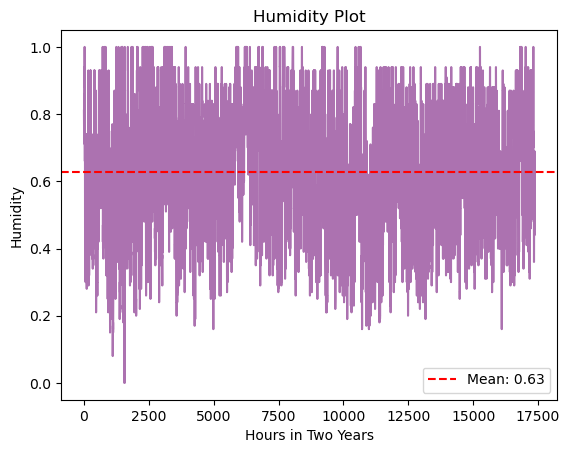

In [3]:
### Exploratory Analyse to Statement 1
## Humidity
plt.style.use('default')


plt.plot(data['hum'], color= '#AC72B0')


mean_hum = data['hum'].mean()

plt.axhline(y=mean_hum, color='r', linestyle='--', label=f'Mean: {mean_hum:.2f}')

plt.title("Humidity Plot")
plt.xlabel("Hours in Two Years")
plt.ylabel("Humidity")
plt.legend(loc = 'lower right')
plt.show()


From the exploratory analysis of the humidity variable, we observe that the majority of the humidity values throughout the year range between 0.2 and 1.0. The average humidity is approximately 0.63, as indicated by the red dashed line in the plot.

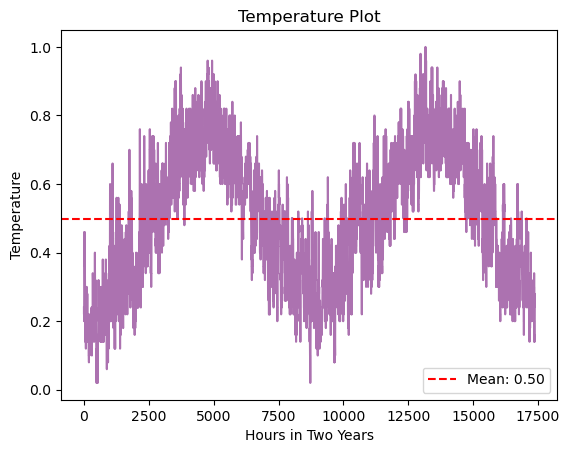

In [4]:
### Exploratory Analyse to Statement 1
## Temperature
plt.style.use('default')


plt.plot(data['temp'], color = '#AC72B0')
mean_temp = data['temp'].mean()

plt.axhline(y=mean_temp, color='r', linestyle='--', label=f'Mean: {mean_temp:.2f}')

plt.title("Temperature Plot")
plt.xlabel("Hours in Two Years")
plt.ylabel("Temperature")
plt.legend(loc = 'lower right')
plt.show()

From the exploratory analysis of the temperature variable, it can be observed that the values exhibit a cyclical pattern, likely reflecting seasonal variations. The temperature values range between 0.0 and 1.0, with an average of 0.50, as indicated by the red dashed line. This suggests a relatively balanced distribution of temperature over the observed period, with peaks and troughs that highlight periodic changes.

In [5]:
### Regression Analysis to Statement 1
X = data[['hum', 'temp']]
X = sm.add_constant(X)
y = data['cnt']

model = sm.OLS(y, X).fit()


print("Regression Coefficients:")
print(f"Beta_0 (Intercept): {model.params['const']:.4f}")
print(f"Beta_1 (Humidity - hum): {model.params['hum']:.4f}")
print(f"Beta_2 (Temperature - temp): {model.params['temp']:.4f}")

print("\nFull Regression Summary:")
print(model.summary())

Regression Coefficients:
Beta_0 (Intercept): 184.2446
Beta_1 (Humidity - hum): -278.3578
Beta_2 (Temperature - temp): 361.8051

Full Regression Summary:
                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     2913.
Date:                Sat, 07 Dec 2024   Prob (F-statistic):               0.00
Time:                        15:37:08   Log-Likelihood:            -1.1253e+05
No. Observations:               17379   AIC:                         2.251e+05
Df Residuals:                   17376   BIC:                         2.251e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|   

The regression results show that humidity negatively affects daily bike rental counts($ \Beta_{\text{humidity}} $ = -278.3578, p < 0.05), while temperaturety has positive effect ($ \Beta_{\text{temperature}} $ = 361.8051, p < 0.05). The model explains 25.1% of the variation in bike rentals R^2 = 0.251.

Interpretation of the Model

- **R-squared**: The R-squared value of 0.251 indicates that humidity and temperature together explain 25.1% of the variation in bike rental counts. Although this is a moderate level of explanatory power, it underscores the importance of temperature and humidity as influential factors in rental demand.

- **Model Significance**: The F-statistic is 2913, with a p-value less than 0.001, indicating that at least one predictor in the model is statistically significant. This means that either temperature or humidity, or both, are signficant. This confirms the individual p-values incidating that both humidity and temperature are signficiant predicators to bike rental count.

### Statement 2 Analysis
How does Workingday Status affect bike rental counts?
- Would there be more bike being rented on working days compared to non-working days?

In [ ]:
# regression
X = data['workingday']
y = data['cnt']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     15.95
Date:                Sat, 07 Dec 2024   Prob (F-statistic):           6.52e-05
Time:                        15:37:08   Log-Likelihood:            -1.1503e+05
No. Observations:               17379   AIC:                         2.301e+05
Df Residuals:                   17377   BIC:                         2.301e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        181.4053      2.442     74.296      0.0

The F-statistic is 15.95 with a very small p-value of 6.52e-05, meaning that the overall model is significant. The adjusted R-squared value of the model is 0.001, which means only 0.1% of the data can be explained using this model, which means that workday may not be significantly contributing to the prediction of the bike rental counts. However, by looking at the t-statistics and its associated p-value, we reject the null hypothsis and working day is associated with a higher number of daily bike rental counts.

In [7]:
# T test
# compare the mean of non-workday to workdays
workday = data[data['workingday'] == 1].cnt
non_workday = data[data['workingday'] == 0].cnt
tstatH, pvalH = stats.ttest_ind(a=workday, b=non_workday, equal_var=False)[:]
print(f'The tstat is {round(tstatH, 3)} and the pval is {pvalH}.')

The tstat is 4.095 and the pval is 4.249478377549554e-05.


In the cell above, we conducted a t-test to compare the average daily bike rental count for working days and non-working days. We received a t-statistics of 4.095 and a p-value of 4.250e-05. The p-value is significantly less than the alpha value 0.05. Therefore, there is enough evidence suggesting that working day is associated with a higher number of daily bike rental counts.

<Axes: xlabel='workingday', ylabel='cnt'>

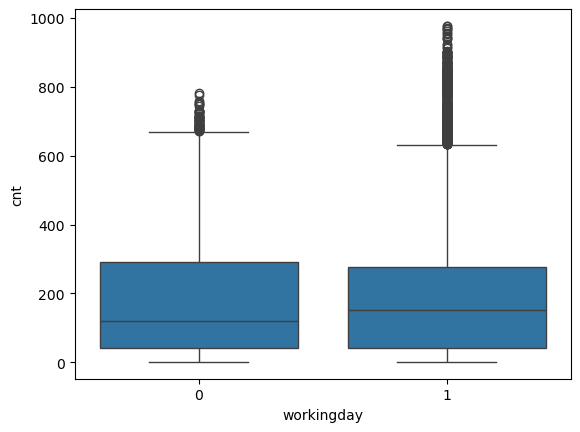

In [8]:
# create a graph comparing workday and non-workday
sns.boxplot(data=data, x='workingday', y='cnt')

As shown by the boxplot above, the total bike rental counts seem to be lower on non-working days compared to working days. This plot matches with our conclusion from the previous regression analysis that working day is associated with a higher number of daily bike rental counts.

#### Question: On which weekday will there be more bikes being rented?

In [9]:
# convert day of the week into dummy variables
weekday_dummy = pd.get_dummies(data['weekday'])
weekday_dummy = weekday_dummy.rename(columns={0:'Sun', 1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat'})

In [10]:
# regression
y = data['cnt']
X = weekday_dummy.astype(int)
X = sm.add_constant(X)

model_day = sm.OLS(y, X).fit()
model_day.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     2.869
Date:                Sat, 07 Dec 2024   Prob (F-statistic):            0.00541
Time:                        15:37:08   Log-Likelihood:            -1.1503e+05
No. Observations:               17379   AIC:                         2.301e+05
Df Residuals:                   17371   BIC:                         2.301e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.272e+13    1.4e+13      0.908      0.364   -1.47e+13    4.02e+13
Sun        -1.272e+13    1.4e+13     -0.908      0.364   -4.02e+13    1.47e+13
Mon        -1.272e+13    1.4e+13     -0.908      0.364   -4.02e+13    1.47e+13
Tue        -1.272e+13    1.4e+13     -0.908      0.364   -4.02e+13    1.47e+13
Wed        -1.272e+13    1.4e+13     -0.908      0.364   -4.02e+13    1.47e+13
Thu        -1.272e+13    1.4e+13     -0.908      0.364   -4.02e+13    1.47e+13
Fri        -1.272e+13    1.4e+13     -0.908      0.364   -4.02e+13    1.47e+13
Sat        -1.272e+13    1.4e+13     -0.908      0.364   -4.02e+13    1.47e+13
==============================================================================
Omnibus:                     3438.326   Durbin-Watson:                   0.313
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             6109.819
Skew:                           1.273   Prob(JB):                         0.00
Kurtosis:                       4.397   Cond. No.                     3.08e+13
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 2.09e-23. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

The F-statistic is 2.987 with a small p-value of 0.00392, meaning that the overall model is significant. The adjusted R-squared value of the model is 0.001, which means only 0.1% of the data can be explained using this model, which means that weekday may not be significantly contributing to the prediction of the bike rental counts.

The p-values for each dummy variables, surprisingly are all the same (0.899), which are much larger than 0.05. Therefore, we fail to reject the null hypothesis and the difference in weekdays does not affect the daily bike rental counts.

<Axes: xlabel='weekday', ylabel='cnt'>

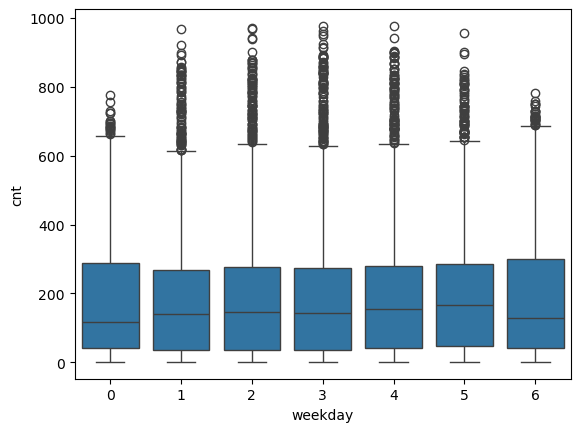

In [11]:
# plot a box graph of weekday vs daily bike rental counts
sns.boxplot(data=data, x='weekday', y='cnt')

From the boxplot, we can tell that Saturday and Sunday have the lowest amount of daily bike rental counts. There aren't any significance difference in the mean bike rental counts during the weekday, but Friday has a little more bike rentals. However, none of the differences are big enough and that may be the reason why none of the weekdays are significant in the above regression analysis.

We decided to conduct an ANOVA test to explore if the difference in each day of the week are associated with the difference in the bike rental counts of that day.

In [12]:
# ANOVA TEST for weekday
model = ols('cnt ~ C(weekday)', data = data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(weekday),6.879294e+05,6.0,3.48779,0.001899
Residual,5.710737e+08,17372.0,NaN,NaN


This ANOVA model has a f-statistic of 3.48779 and a p-value of 0.0019, indicating there is significant difference between the means of each group. Therefore, the change in different days of the week does lead to a significant difference in the bike rental counts for each day. However, this result is based on several mean differences together and we didn't know if there are any false positives lying under. So we decideed to conduct a Tuckey test to check pair-wise differences.

In [13]:
# Conduct a Tukey Test to check for pair-wise comparisons
tukey = pairwise_tukeyhsd(endog=data['cnt'],
                          groups=data['weekday'],
                          alpha=0.05)
tukey.summary()

/opt/anaconda3/envs/info2950/lib/python3.12/site-packages/scipy/integrate/_quadpack_py.py:1260: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


group1,group2,meandiff,p-adj,lower,upper,reject
0,1,6.2758,0.8861,-8.8745,21.4262,False
0,2,13.7701,0.1052,-1.4206,28.9607,False
0,3,13.6617,0.1092,-1.4948,28.8182,False
0,4,18.9678,0.0042,3.8052,34.1305,True
0,5,18.6671,0.0052,3.529,33.8052,True
0,6,12.741,0.1636,-2.3593,27.8413,False
1,2,7.4942,0.7736,-7.7313,22.7197,False
1,3,7.3858,0.7836,-7.8056,22.5773,False
1,4,12.692,0.1732,-2.5056,27.8896,False
1,5,12.3913,0.195,-2.7818,27.5643,False


From this summary, we can tell that the bike rental counts on Sunday is significantly different than the bike rental counts on Thursdays and Fridays. Therefore, Saturdays probably have a very different bike rental counts in the week.

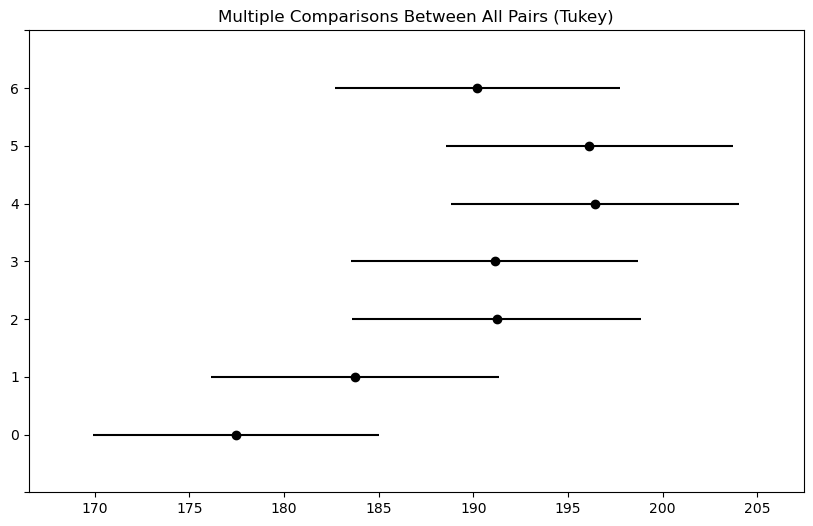

In [14]:
tukey.plot_simultaneous();

The 95% confidence interval plot reinforces the results visually: the confidence interval of Friday and Thursday do no overlap with the confidence interval of Sunday.

#### Question: Does time of the day effect the number of bike rental counts?

In [15]:
# convert time of the day into dummy variables
time_dummy = pd.get_dummies(data['time_period'])
time_dummy = time_dummy.rename(columns={1:'dawn', 2:'morning', 3:'afternoon', 4:'night'})

In [16]:
# regression
y = data['cnt']
X = time_dummy.astype(int)
X = sm.add_constant(X)
model_day = sm.OLS(y, X).fit()
model_day.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.301
Model:                            OLS   Adj. R-squared:                  0.301
Method:                 Least Squares   F-statistic:                     1872.
Date:                Sat, 07 Dec 2024   Prob (F-statistic):               0.00
Time:                        15:37:09   Log-Likelihood:            -1.1193e+05
No. Observations:               17379   AIC:                         2.239e+05
Df Residuals:                   17374   BIC:                         2.239e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8.263e+11   1.09e+13      0.076      0.940   -2.06e+13    2.22e+13
dawn       -8.263e+11   1.09e+13     -0.076      0.940   -2.22e+13    2.06e+13
morning    -8.263e+11   1.09e+13     -0.076      0.940   -2.22e+13    2.06e+13
afternoon  -8.263e+11   1.09e+13     -0.076      0.940   -2.22e+13    2.06e+13
night      -8.263e+11   1.09e+13     -0.076      0.940   -2.22e+13    2.06e+13
==============================================================================
Omnibus:                     4133.738   Durbin-Watson:                   0.518
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             9710.763
Skew:                           1.335   Prob(JB):                         0.00
Kurtosis:                       5.506   Cond. No.                     2.37e+13
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 3.86e-23. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

The F-statistic is 1872 with a very small p-value of 0.00, meaning that the overall model is significant. The adjusted R-squared value of the model is 0.301, which means about 30.1% of the data can be explained using this model.

The p-values for each dummy variables are 0.920, which is significantly higher than the threshold of 0.05. This means we fail to reject the null hypothesis and time of the day does not have an effect on the daily bike rental counts.

## Evaluation of Significance

### Evaluation of Significance for Statement 1

Based on the regression analysis results, here is an evaluation of statistical significance, along with clear interpretations and conclusions derived from the findings.ance

In this analysis, we examined the effects of humidity (`hum`) and temperature (`temp`) on bike rental counts (`cnt`). The regression coefficients and associated p-values offer valuable insights into these relationships.

- **Intercept (β0)**: 1096.9971, with a p-value of 0.000. This value represents the baseline bike rental count when humidity and temperature are both zero. Although zero values for humidity and temperature are unlikely in practice, this intercept provides a reference point for the model.

- **Humidity (β1)**: -1647.7155, with a p-value of 0.000. The negative coefficient indicates that an increase in humidity significantly decreases bike rental counts. The 95% confidence interval ([-1785.131, -1510.300]) suggests that this negative effect is statistically significant. The low p-value (<0.05) further confirms the high statistical significance of this relationship.

- **Tempebeta (β2)**: 2153.8927, with a p-value of 0.000. The positive coefficient suggests that an increase in temperature significantly increases bike rental counts. The 95% confidence interval ([2023.383, 2284.402]) confirms that this positive impact is statistically significant, with the p-value also well below 0.05, emphasizing a strong positive relationship between temperature and rental counts.

### Evaluation of Significance for Statement 2
In this analysis, we examined the effects of workingday on bike rental counts along with the effects of weekday and time period. 
- **workingday**: From the model, we have a t-statistics of 4.095 and a p-value of 4.250e-05. The p-value is significantly less than the alpha value 0.05. Therefore, there is enough evidence suggesting that working day is associated with a higher number of daily bike rental counts.

- **weekday**: The p-value for weekday is 0.899, which is significantly larger than 0.05. This means that we fail to reject the null hypothesis and there isn't enough evidence to support a significant relationship with the weekday and bike rental counts.

- **time period**: The p-value for time period is 0.920, which is significantly larger than 0.05. This means that we fail to reject the null hypothesis and there isn't enoughe vidence to support a significant relationship between the time period and bike rental counts.

## Conclusion

### Conclusion and Insights For Statement 1

Overall, temperature and humidity have opposite and significant effects on bike rental counts. Higher temperatures substantially increase rental demand, while higher humidity significantly decreases it. These findings lead to several practical conclusions:

- Bike rental demand is likely higher in warm, dry weather conditions.
- Monitoring weather conditions can support better planning and management of bike rental services to meet higher demand on favorable days.

This report presents a coherent analysis of the significance of temperature and humidity on bike rental counts, providing a data-driven basis for decision-making. The results highlight the different impacts of these factors, offering clear, actionable insights.

### Conclusion and Insights For Statement 2

**Working Day vs Bike Rental Counts**  
There is a significant relationship between workingday and bike rental counts. From the model, we can conclude that compared to being on weekends, a weekday is asssociated with a higher number of daily bike rental counts. However, this model has a adjsuted R value of 0.01, which indicates that working day alone is not enough to predict the bike rental counts.  

**Weekday vs Bike Rental Counts**  
There is no significant relationship between the day of the week and total bike rental counts according to the regression model. However, according to the following Tuckey test, there is significant differnce in the total bike rental counts between Thursday and Sunday, and Friday and Sunday.  

**Time Period vs Bike Rental Counts**  
There is no significant relaitonship between the time of the day and the total bike rental counts according to the regression model.


## Limitations
1. Simplification of Environmental and Temporal Variables:  
The dataset applies normalized values for temperature, humidity, and wind speed to reduce variance in the model, but this may obscure the impact of extreme weather conditions on bike rentals. Additionally, aggregating hourly data into four time periods and selecting the primary weather condition within each period may overlook important short-term weather patterns that influence user behavior. This could affect the model's ability to capture fluctuations in bike demand under rapidly changing conditions.

2. Multicollinearity Among Independent Variables:  
There may be multicollinearity between variables such as working days, holidays, and weekdays due to their interdependence. This overlap increases the complexity of the model, making it more difficult to interpret the contribution of individual variables. Misinterpretation of the model could mislead decision-makers, resulting in inefficient resource allocation or policy decisions that fail to meet users' actual needs.

3. Limited Data Coverage:  
The dataset is limited to bike rental data from the Capital Bikeshare system in Washington, D.C., covering only the years 2011 to 2012. This temporal and geographical constraint may lead to data gaps, as the results might not generalize to other periods or locations with different usage patterns. Such limitations could affect the validity of predictions and insights, potentially leading to misinformed resource allocation or policy decisions if applied in contexts beyond the original dataset’s scope. 

4. Data Limitation Across Date:  
This dataset is divided into categories based on the time of day, which means each day is further segmented into four distinct parts. As a result, when we calculate the relationship between bike rental counts and each day as a whole, the lack of statistical significance in the results could be attributed to this segmentation. Splitting each day into four parts might hide any substantial variations that occur across the entire day, as the data within each time segment may exhibit relatively minimal changes.

5. Social Behavior:  
The rental behavior on working days and non-working days may vary due to differences in population distribution or regional activities, such as commuting on working days or recreational outings on non-working days. On working days, urban areas or business districts may see higher rental demand due to people commuting to and from work. On non-working days, the rental patterns might shift, with residential or tourist-heavy areas becoming more active due to leisure activities.

## Acknowledgements and Bibliography

### Acknowledgements
The Bike Sharing Dataset we used for this project is from UCI Machine Learning Repository. To analyze the data, we used statistical techniques covered in class and ANOVA and Tukey's test. We referred to external resources to learn and implement ANOVA and Tukey's test, including in the Bibliography below. These resources were extremely helpful and important to our project.

### Bibliography
Fanaee-T, Hadi, and Gama, João. “Bike Sharing Dataset.”  
&nbsp;&nbsp;&nbsp;&nbsp;*UCI Machine Learning Repository*, University of California, Irvine,  
&nbsp;&nbsp;&nbsp;&nbsp;https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset.

“ANOVA - Analysis of Variance.” *Statsmodels Documentation*,  
&nbsp;&nbsp;&nbsp;&nbsp;https://www.statsmodels.org/stable/anova.html. 

“Perform a Tukey Test in Python (Step-by-Step).”  
&nbsp;&nbsp;&nbsp;&nbsp;*Statology*, https://www.statology.org/tukey-test-python/. 

